In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

## **Data Loading and Initial Look**

In [4]:
df = pd.read_csv('fetal_health.csv')

In [5]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['fetal_health'].value_counts().sort_index())

Dataset Shape: (2126, 22)

Missing Values:
 baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                              

## **Data Visualization & Feature Summary**

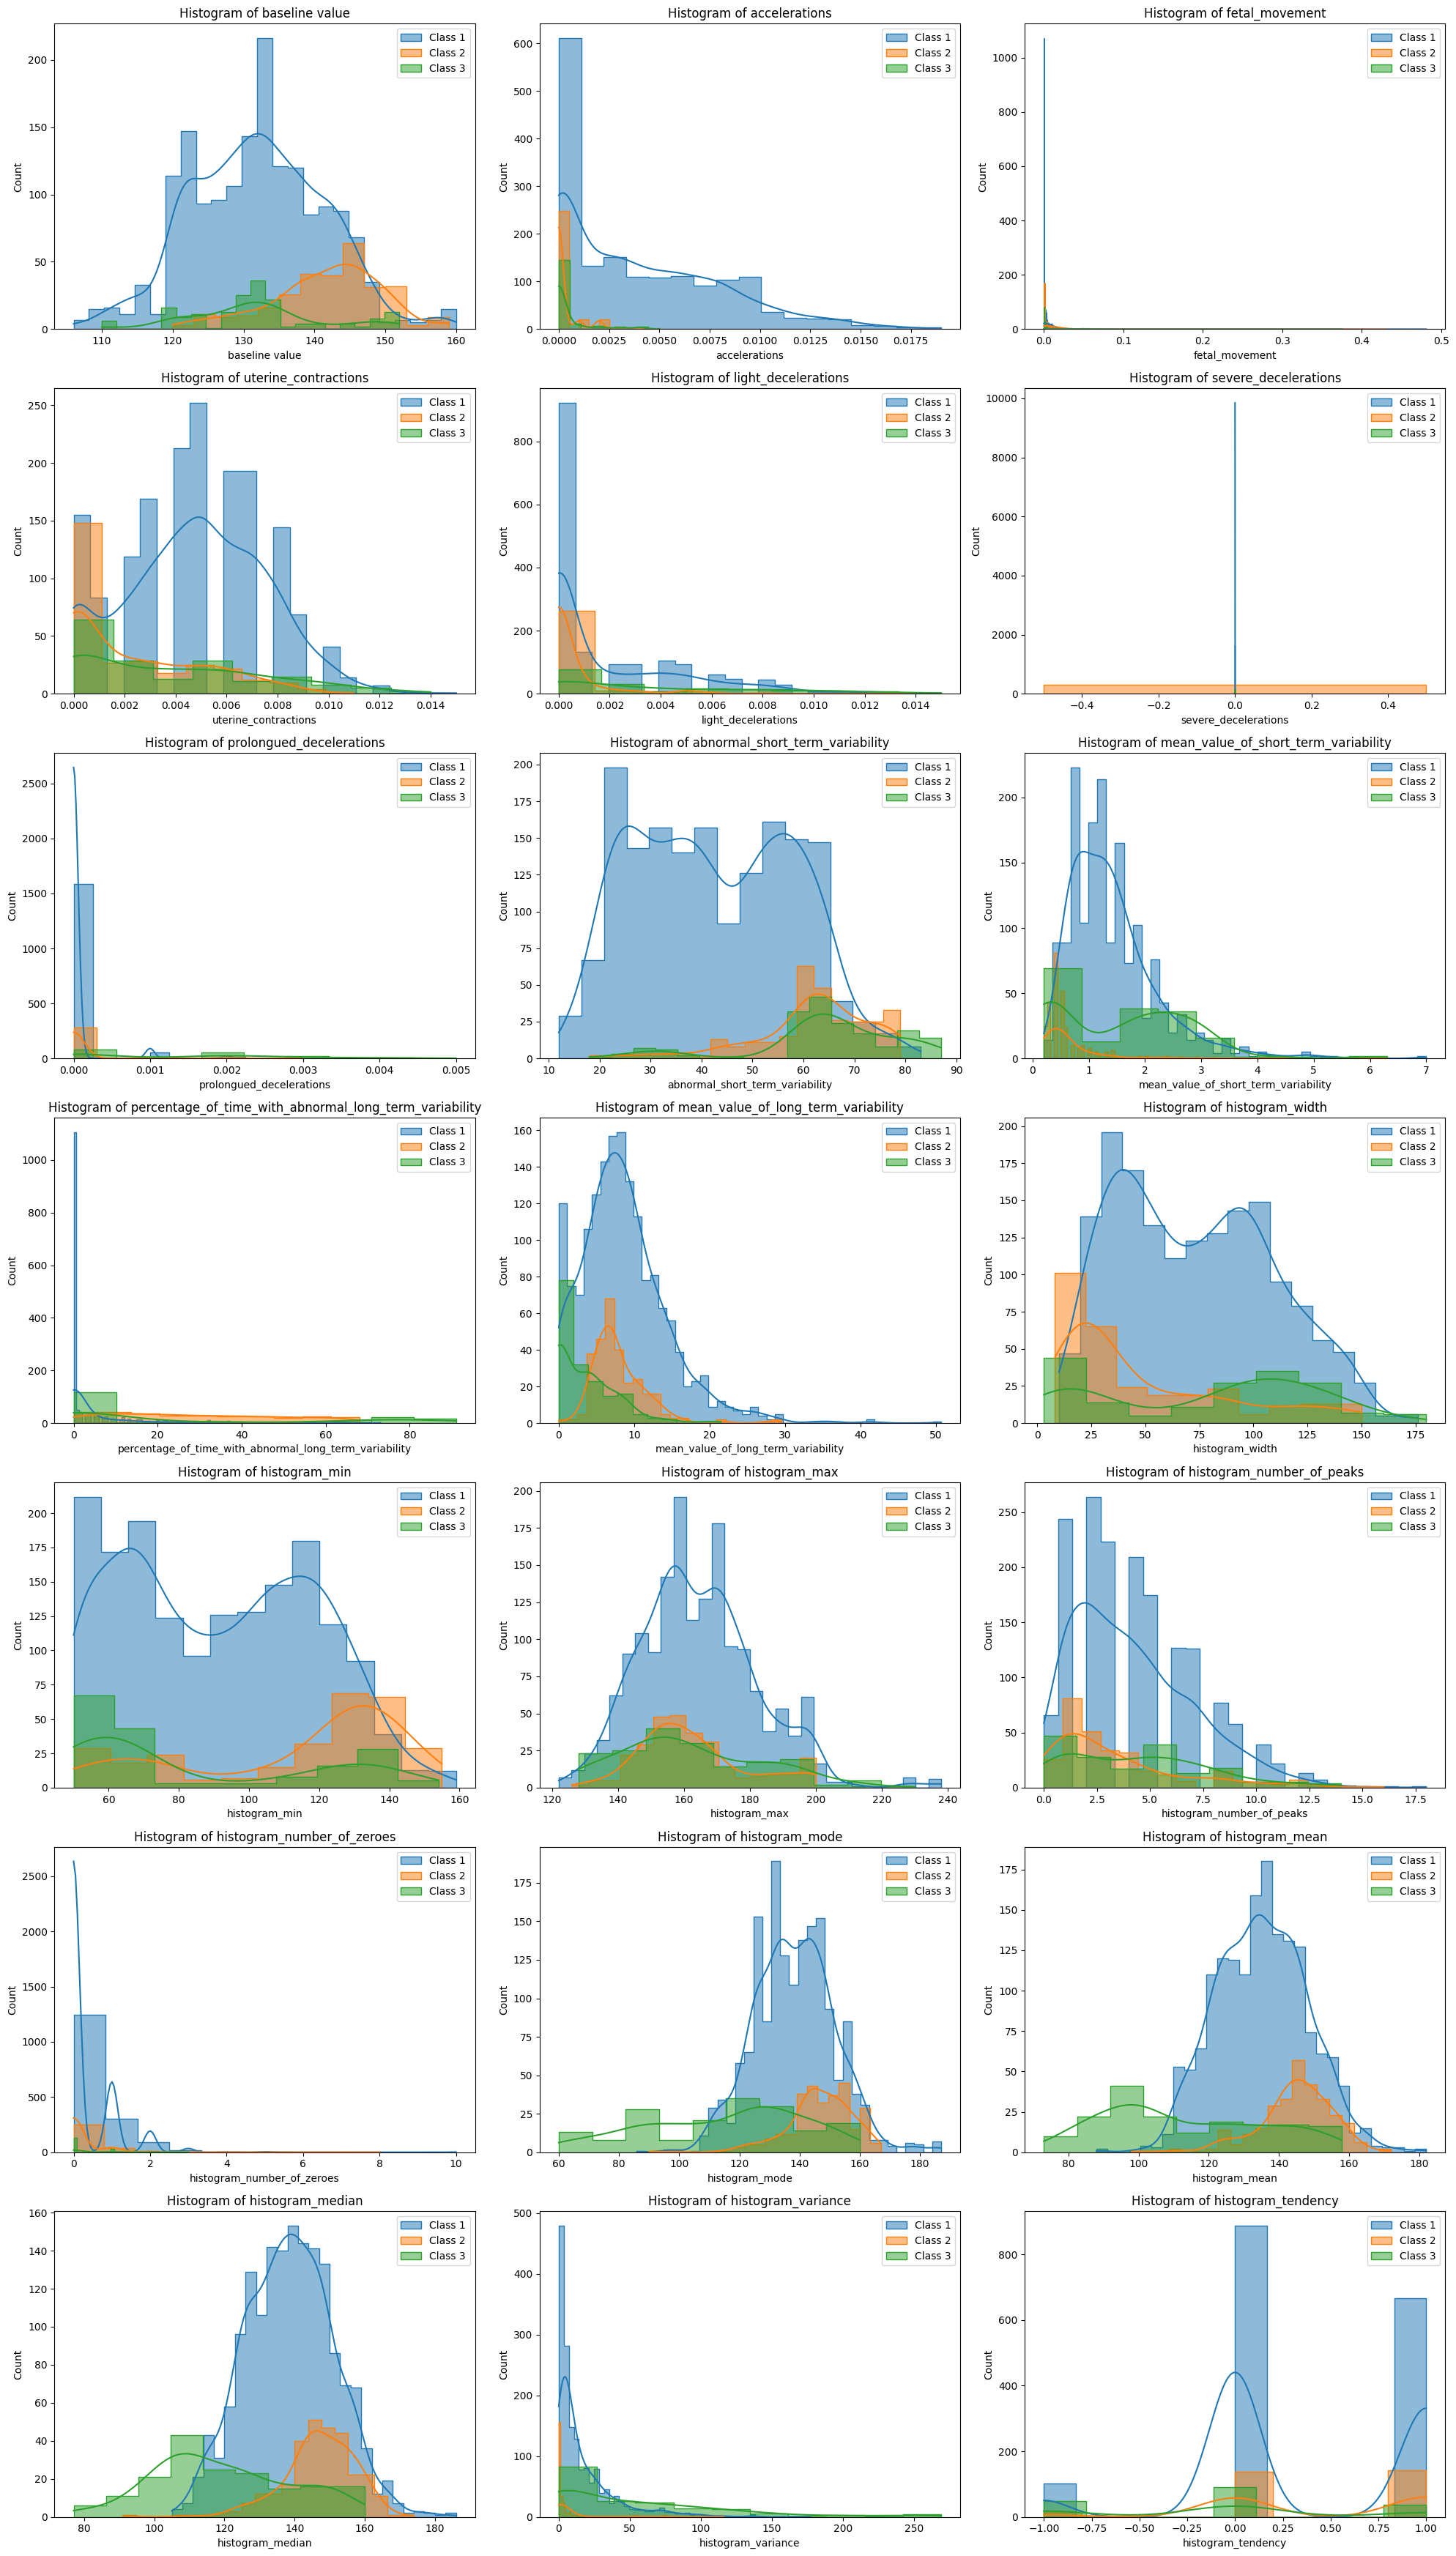

In [9]:
features = df.columns[:-1]
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))
for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    for target_class in sorted(df['fetal_health'].unique()):
        subset = df[df['fetal_health'] == target_class]
        sns.histplot(subset[feature], label=f'Class {int(target_class)}', kde=True, element="step")
    plt.title(f'Histogram of {feature}')
    plt.legend()
plt.tight_layout()
plt.savefig('histograms_features_vs_class.png')

summary_data = []
for col in df.columns:
  col_type = 'Numerical'
  unique_vals = df[col].unique()
  if len(unique_vals) <= 10:
    cols_type = 'Categorical'
    vals = ",".join([str(v) for v in sorted (unique_vals)])
  else:
    vals = f"{df[col].min()} to {df[col].max()}"

  missing = df[col].isnull().sum()

  mean = df[col].mean()
  std = df[col].std()
  outliers = ((df[col] < (mean - 3 * std)) | (df[col] > (mean + 3 * std))).sum()

  summary_data.append({
      'Feature': col,
      'Type': col_type,
      'Value/Range': vals,
      'Missing Values': missing,
      'Outliers (3-sigma)': outliers
  })
summary_table = pd.DataFrame(summary_data)
summary_table.to_csv('feature_summary.csv', index=False)

## **Data Cleaning and Preparation**

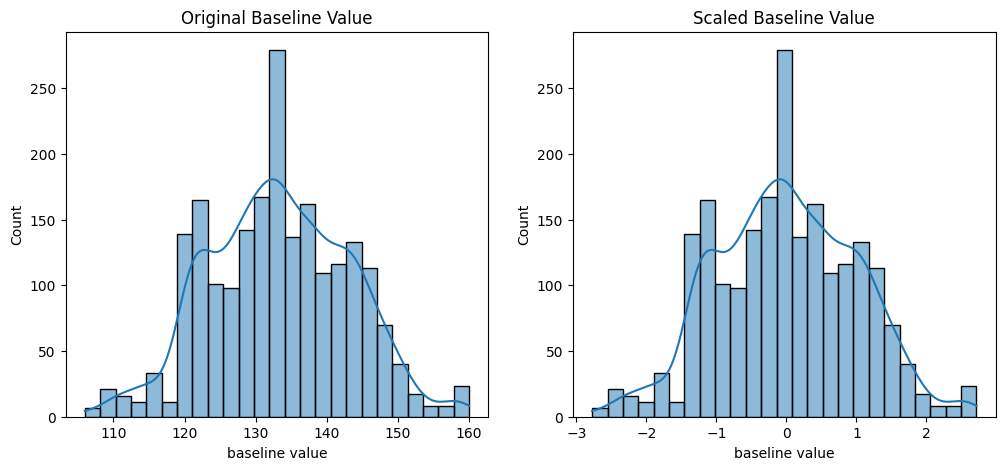

In [12]:
X = df.drop(columns=['fetal_health'])
y = df['fetal_health']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

fig, axes = plt.subplots(1,2, figsize=(12, 5))
sns.histplot(df['baseline value'], kde=True, ax=axes[0]).set_title('Original Baseline Value')
sns.histplot(X_scaled_df['baseline value'], kde=True, ax=axes[1]).set_title('Scaled Baseline Value')
plt.savefig('scaling_comparison.png')

## **Machine Learning**

In [13]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)
print("\n--- Validation Performance ---")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

y_test_pred = rf.predict(X_test)
print("\n--- Test Performance ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

submission = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
submission.to_csv('fetal_health_predictions.csv', index=False)


--- Validation Performance ---
Accuracy: 0.9317647058823529
              precision    recall  f1-score   support

         1.0       0.95      0.97      0.96       331
         2.0       0.83      0.75      0.79        59
         3.0       0.94      0.86      0.90        35

    accuracy                           0.93       425
   macro avg       0.90      0.86      0.88       425
weighted avg       0.93      0.93      0.93       425


--- Test Performance ---
Accuracy: 0.931924882629108
              precision    recall  f1-score   support

         1.0       0.95      0.98      0.97       332
         2.0       0.82      0.71      0.76        59
         3.0       0.88      0.86      0.87        35

    accuracy                           0.93       426
   macro avg       0.89      0.85      0.87       426
weighted avg       0.93      0.93      0.93       426



## **Feature Importance**


Processing complete. Files and plots generated.


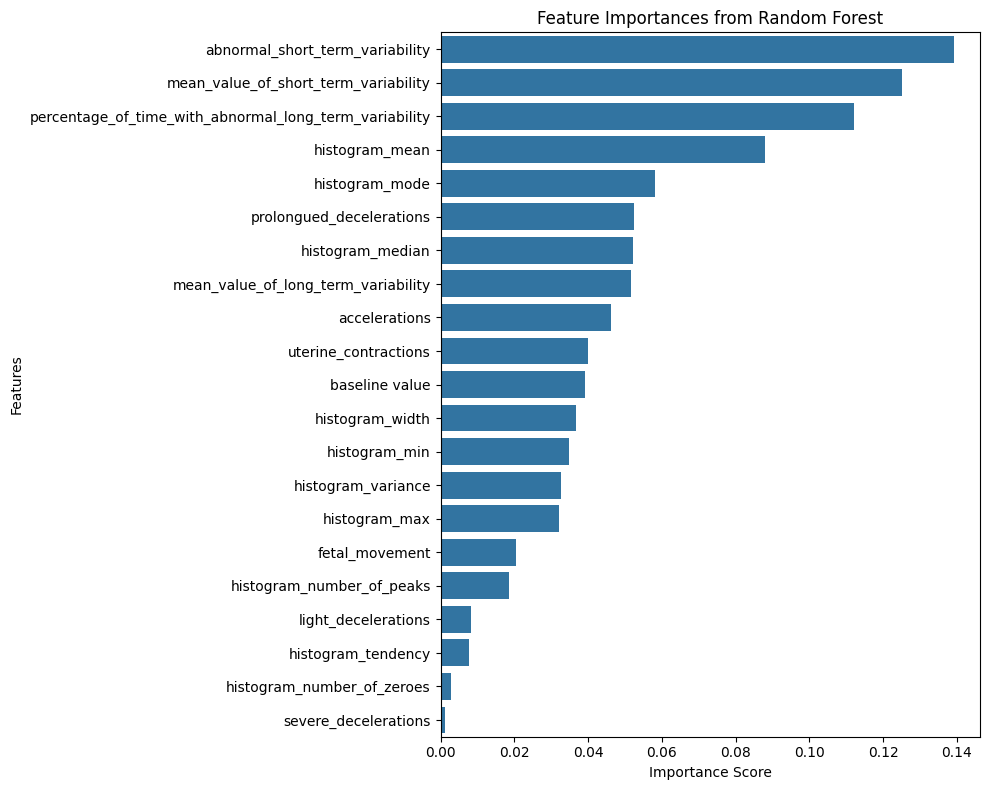

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=importances, y=importances.index)
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('feature_importance.png')

print("\nProcessing complete. Files and plots generated.")